# Set up 

In [126]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [127]:
df = pd.read_csv("../data/clean/spotify_features.csv")

In [128]:
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,...,album_total_tracks,album_type,track_duration_min,release_year,primary_genre,genre_grouped,relative_track_position,release_decade,log_artist_followers,high_popularity
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,False,Britney Spears,80.0,17755451.0,pop,325wcm5wMnlfjmKZ8PXIIn,...,58,compilation,3.55,2009,pop,pop,0.982759,2000s,16.692203,0
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,False,BUNT.,69.0,293734.0,stutter house,2ArRQNLxf9t0O0gvmG5Vsj,...,1,single,2.65,2023,stutter house,Other,1.000000,2020s,12.590433,0
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,False,Taylor Swift,100.0,145396321.0,Unknown,4hDok0OAJd57SGIT8xuWJH,...,26,album,3.76,2021,Unknown,Unknown,0.423077,2020s,18.794974,0
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,True,Billie Eilish,90.0,118692183.0,Unknown,0JGOiO34nwfUdDrD612dOp,...,16,album,2.64,2021,Unknown,Unknown,0.125000,2020s,18.592044,1
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,False,Rihanna,90.0,68997177.0,Unknown,5QG3tjE5L9F6O2vCAPph38,...,13,album,4.45,2010,Unknown,Unknown,0.538462,2010s,18.049576,0


----

# Creating 'track_group' column
### Label that says: "this lines are the exact same music"

In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8775 entries, 0 to 8774
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   track_id                 8775 non-null   str    
 1   track_name               8775 non-null   str    
 2   track_number             8775 non-null   int64  
 3   track_popularity         8775 non-null   int64  
 4   explicit                 8775 non-null   bool   
 5   artist_name              8773 non-null   str    
 6   artist_popularity        8772 non-null   float64
 7   artist_followers         8772 non-null   float64
 8   artist_genres            8775 non-null   str    
 9   album_id                 8775 non-null   str    
 10  album_name               8775 non-null   str    
 11  album_release_date       8775 non-null   str    
 12  album_total_tracks       8775 non-null   int64  
 13  album_type               8775 non-null   str    
 14  track_duration_min       8775 non-n

In [130]:
df.isna().sum()

track_id                   0
track_name                 0
track_number               0
track_popularity           0
explicit                   0
artist_name                2
artist_popularity          3
artist_followers           3
artist_genres              0
album_id                   0
album_name                 0
album_release_date         0
album_total_tracks         0
album_type                 0
track_duration_min         0
release_year               0
primary_genre              0
genre_grouped              0
relative_track_position    0
release_decade             0
log_artist_followers       3
high_popularity            0
dtype: int64

In [131]:
df['artist_name'] = df['artist_name'].fillna('Unknown')   

In [132]:
df['track_group'] = df['track_name'] + " " + df['artist_name']

In [133]:
df["track_group"].nunique()

7924

In [134]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8775 entries, 0 to 8774
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   track_id                 8775 non-null   str    
 1   track_name               8775 non-null   str    
 2   track_number             8775 non-null   int64  
 3   track_popularity         8775 non-null   int64  
 4   explicit                 8775 non-null   bool   
 5   artist_name              8775 non-null   str    
 6   artist_popularity        8772 non-null   float64
 7   artist_followers         8772 non-null   float64
 8   artist_genres            8775 non-null   str    
 9   album_id                 8775 non-null   str    
 10  album_name               8775 non-null   str    
 11  album_release_date       8775 non-null   str    
 12  album_total_tracks       8775 non-null   int64  
 13  album_type               8775 non-null   str    
 14  track_duration_min       8775 non-n

-----


## Preparing the data

**Target:** 'high_popularity' (classification).

### Feature set: Model A

Model A uses only characteristics of the track and its release, as defined in '05_feature_engineering.ipynb'. It excludes 'artist_popularity' and 'artist_followers', following the main research question in '00_business_background.ipynb': whether track popularity can be predicted without relying on the artist's existing fame.

Model B, which adds the two artist-level features, will be built afterwards as a benchmark.

In [135]:
# X-y split; features = X, target = y
model_a_features = ["track_duration_min", "album_total_tracks", "relative_track_position", "explicit", "genre_grouped", "album_type", "release_decade"]
features = df[model_a_features]

target = df["high_popularity"]    #what we want to predict  

In [136]:
features.columns.tolist()

['track_duration_min',
 'album_total_tracks',
 'relative_track_position',
 'explicit',
 'genre_grouped',
 'album_type',
 'release_decade']

### Grouped split

The dataset contains 697 songs that appear under more than one 'track_id': typically the album version and the single release. 
A random split would place copies of the same song in both the training and test sets, letting the model recognise a track it has already seen rather than predict it.

'GroupShuffleSplit' is used instead, grouping by 'track_group' so that all versions of a song fall entirely on one side of the split.

In [137]:
from sklearn.model_selection import GroupShuffleSplit

In [138]:
groups = df["track_group"]

In [139]:
splitter = GroupShuffleSplit(test_size=0.20, random_state=0)

In [140]:
# now we have to know where to "cut": 
## GroupShuffleSplit returns row positions, not the data itself
## we use .iloc to retrieve the corresponding rows

In [141]:
train_idx, test_idx = next(splitter.split(features, target, groups=groups))

In [142]:
print(train_idx[:10])

[ 0  2  4  8  9 10 11 12 13 14]


In [143]:
X_train = features.iloc[train_idx]   # feature rows used to train the model
X_test  = features.iloc[test_idx]    # feature rows for evaluation
y_train = target.iloc[train_idx]     # the correct answers for the training rows
y_test  = target.iloc[test_idx]      # the correct answers for the held-back rows

In [144]:
X_train.head(10)

,track_duration_min,album_total_tracks,relative_track_position,explicit,genre_grouped,album_type,release_decade
0,3.55,58,0.982759,False,pop,compilation,2000s
2,3.76,26,0.423077,False,Unknown,album,2020s
4,4.45,13,0.538462,False,Unknown,album,2010s
8,3.81,16,0.937500,False,soft pop,album,2010s
9,2.58,1,1.000000,False,Unknown,single,2020s
10,3.68,19,0.789474,False,pop,album,2010s
11,1.62,1,1.000000,True,Other,single,2020s
12,3.47,13,0.846154,False,pop,album,2000s
13,3.96,1,1.000000,False,edm,single,2020s
14,3.13,1,1.000000,False,Unknown,single,2020s


In [145]:
X_train.shape

(6996, 7)

In [146]:
X_test.shape

(1779, 7)

### The resulting split is 6,996 training rows and 1,779 test rows, which is ~79.7% / ~20.3% rather than exactly 80/20. 
> This is expected: 'GroupShuffleSplit' divides the data by groups rather than by rows, and groups vary in size, so the proportion is approximate.

#### The cell below confirms that no song appears on both sides of the split:

In [147]:
train_songs = groups.iloc[train_idx]
test_songs  = groups.iloc[test_idx]

print("Songs in both sets:", test_songs.isin(train_songs).sum())

Songs in both sets: 0


### Encoding the categorical features

'OneHotEncoder' turns each categorical column into binary indicator columns, one per category. 'drop='first' removes one category from each feature to avoid the dummy variable trap, where the dropped category is perfectly predictable from the remaining ones.

The encoder is fitted on the training set only. Fitting it on the full dataset would let information about the test set into the training pipeline. '.transform()' is then applied to both sets, so the test set is described using categories the encoder learned from the training data.

Four categorical features become 42 columns.

In [148]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first') # To avoid having an sparse_matrix as output

model_a_categorical = ['explicit', 'genre_grouped', 'album_type', 'release_decade']

ohe.fit(X_train[model_a_categorical]) # The .fit() method determines the unique values of each column
X_train_trans_np = ohe.transform(X_train[model_a_categorical])
X_train_trans_np

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 0.],
       ...,
       [1., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(6996, 42))

In [149]:
X_train_trans_df = pd.DataFrame(X_train_trans_np, columns=ohe.get_feature_names_out(), index=X_train.index)
X_train_trans_df

,explicit_True,genre_grouped_Unknown,genre_grouped_anime,genre_grouped_art pop,genre_grouped_art rock,genre_grouped_bedroom pop,genre_grouped_celtic,genre_grouped_classic rock,genre_grouped_country,genre_grouped_dark r&b,...,genre_grouped_soundtrack,album_type_compilation,album_type_single,release_decade_1960s,release_decade_1970s,release_decade_1980s,release_decade_1990s,release_decade_2000s,release_decade_2010s,release_decade_2020s
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8770,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8771,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8772,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8773,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [150]:
X_test_trans_np = ohe.transform(X_test[model_a_categorical])
X_test_trans_np

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 1., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [1., 1., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 0.]], shape=(1779, 42))

In [151]:
X_test_trans_df = pd.DataFrame(X_test_trans_np, columns=ohe.get_feature_names_out(), index=X_test.index)
X_test_trans_df

,explicit_True,genre_grouped_Unknown,genre_grouped_anime,genre_grouped_art pop,genre_grouped_art rock,genre_grouped_bedroom pop,genre_grouped_celtic,genre_grouped_classic rock,genre_grouped_country,genre_grouped_dark r&b,...,genre_grouped_soundtrack,album_type_compilation,album_type_single,release_decade_1960s,release_decade_1970s,release_decade_1980s,release_decade_1990s,release_decade_2000s,release_decade_2010s,release_decade_2020s
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8763,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8766,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8767,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Scaling the numeric features

'StandardScaler' centres each numeric feature at zero with unit variance. 'album_total_tracks' contains outliers — compilations with very high track counts — and 'StandardScaler' handles those better than 'MinMaxScaler', which would squeeze the rest of the distribution into a narrow band at the bottom of the range.

As with the encoder, the scaler is fitted on the training set only.

The one-hot columns are already 0/1 by construction, so they are not scaled.

In [152]:
scaler = StandardScaler()
model_a_numerical = ['track_duration_min', 'album_total_tracks', 'relative_track_position']

scaler.fit(X_train[model_a_numerical])

X_train_scaled_np = scaler.transform(X_train[model_a_numerical])
X_test_scaled_np  = scaler.transform(X_test[model_a_numerical])

X_train_standarized = pd.DataFrame(X_train_scaled_np, columns=model_a_numerical, index=X_train.index)
X_test_standarized  = pd.DataFrame(X_test_scaled_np, columns=model_a_numerical, index=X_test.index)

In [153]:
X_train_standarized.describe()

,track_duration_min,album_total_tracks,relative_track_position
count,6.996000e+03,6.996000e+03,6.996000e+03
mean,4.895392e-16,1.955110e-17,-2.092221e-16
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-3.158409e+00,-1.079826e+00,-1.582916e+00
25%,-5.749788e-01,-6.614865e-01,-9.240298e-01
50%,-4.420125e-02,-7.581065e-02,-1.364741e-01
75%,4.583934e-01,2.588613e-01,1.138881e+00
max,9.401760e+00,1.398041e+01,1.326129e+00


In [154]:
X_train_full = pd.concat([X_train_trans_df, X_train_standarized], axis=1)
X_test_full  = pd.concat([X_test_trans_df, X_test_standarized], axis=1)

In [155]:
X_train_full.shape

(6996, 45)

In [156]:
X_test_full.shape

(1779, 45)

-----


## Modelling

The preprocessing above produces 45 features: 42 one-hot columns and 3 standardised numeric columns.

In [157]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_full, y_train)
print("Dummy accuracy:", dummy.score(X_test_full, y_test))

Dummy accuracy: 0.7346824058459809


In [158]:
# univariate linear association between the numeric features and the raw popularity score
train_rows = df.iloc[train_idx]
train_rows[model_a_numerical + ["track_popularity"]].corr()["track_popularity"].round(3)

track_duration_min         0.108
album_total_tracks        -0.052
relative_track_position   -0.095
track_popularity           1.000
Name: track_popularity, dtype: float64

### Random Forest

Two reasons for starting with a tree-based ensemble rather than a linear model.

1.**The relationships in this dataset are not linear.** The Pearson correlations between the numeric features and track_popularity on the training set are close to zero (see the cell above). Pearson correlation only measures linear association, so a weak coefficient does not rule out a relationship, it rules out a straight-line one. A decision tree splits each variable into intervals and can capture patterns a linear model cannot represent.

2.**It answers MLQ3 directly.** Random forests expose 'feature_importances_', which is the ranking the third sub-question asks for.

The features were scaled in the previous step. Tree-based models do not need scaling, since a split point is unaffected by a linear rescaling, but scaling does them no harm and keeps the same feature matrix usable for a logistic regression comparison later.

In [159]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)
rf.fit(X_train_full, y_train)
print("RF accuracy:", rf.score(X_test_full, y_test))

RF accuracy: 0.6942102304665543


### Evaluation

On an imbalanced target, accuracy is a misleading single metric: a classifier can score highly while barely identifying the minority class. The confusion matrix and the per-class metrics are what the research question actually needs.

The row for class 1 is the one that matters. 

**Recall** answers: of the tracks that really are hits, how many did the model find? 

**Precision** answers: when the model predicts a hit, how often is it right?

In [160]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test_full)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1109  198]
 [ 346  126]]
              precision    recall  f1-score   support

           0       0.76      0.85      0.80      1307
           1       0.39      0.27      0.32       472

    accuracy                           0.69      1779
   macro avg       0.58      0.56      0.56      1779
weighted avg       0.66      0.69      0.67      1779



In [161]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Tracks predicted as hits:", fp + tp)
print("Of those, real hits:", tp, "->", round(tp / (fp + tp), 3))
print("Base rate of hits in the test set:", round(y_test.mean(), 3))
print("Lift:", round((tp / (fp + tp)) / y_test.mean(), 2))

Tracks predicted as hits: 324
Of those, real hits: 126 -> 0.389
Base rate of hits in the test set: 0.265
Lift: 1.47


### Results — Model A

The dummy classifier got 0.735 accuracy. The Random Forest got 0.694, so it did worse.

That looks bad but it is not a defect of the model. The dummy never predicts a hit, so it never gets a hit wrong. The Random Forest predicted 324 hits and was wrong on 198 of them, and every one of those mistakes costs accuracy.

Accuracy is not the right thing to look at here. Hits are 26.5% of the test set (472 out of 1779). Of the 324 tracks the model called hits, 126 really were hits, which is 38.9%. So when the model says "hit", it is right about 1.5 times more often than picking a track at random. The dummy gives us no way of finding a hit at all, because it never predicts one.

Still, the model only found 126 of the 472 real hits. That is a recall of 0.27.

> The intrinsic track features do carry some signal, but it is weak. They are not enough to predict hits reliably. This answers the main research question: **track popularity cannot be predicted from a track's own characteristics alone with useful accuracy.**

Model B adds the two artist-level features and will show how much of the gap they close.

----

# Model B — adding the artist features

#### Can track popularity be predicted without using the artist's existing fame?

In [162]:
model_b_features = ["artist_popularity", "log_artist_followers", "track_duration_min", "album_total_tracks", "relative_track_position", "explicit", "genre_grouped", "album_type", "release_decade"]
features_b = df[model_b_features]

In [163]:
features_b.columns.tolist()

['artist_popularity',
 'log_artist_followers',
 'track_duration_min',
 'album_total_tracks',
 'relative_track_position',
 'explicit',
 'genre_grouped',
 'album_type',
 'release_decade']

In [164]:
X_train_b = features_b.iloc[train_idx]   # feature rows used to train the model
X_test_b  = features_b.iloc[test_idx]    # feature rows for evaluation

In [165]:
X_train_b.head(10)

,artist_popularity,log_artist_followers,track_duration_min,album_total_tracks,relative_track_position,explicit,genre_grouped,album_type,release_decade
0,80.0,16.692203,3.55,58,0.982759,False,pop,compilation,2000s
2,100.0,18.794974,3.76,26,0.423077,False,Unknown,album,2020s
4,90.0,18.049576,4.45,13,0.538462,False,Unknown,album,2010s
8,88.0,18.625850,3.81,16,0.937500,False,soft pop,album,2010s
9,48.0,11.130596,2.58,1,1.000000,False,Unknown,single,2020s
10,83.0,17.463190,3.68,19,0.789474,False,pop,album,2010s
11,79.0,16.084194,1.62,1,1.000000,True,Other,single,2020s
12,80.0,16.692203,3.47,13,0.846154,False,pop,album,2000s
13,59.0,14.014853,3.96,1,1.000000,False,edm,single,2020s
14,83.0,16.063634,3.13,1,1.000000,False,Unknown,single,2020s


In [166]:
X_train_b.shape

(6996, 9)

In [167]:
X_test_b.shape

(1779, 9)

### Encoding the categorical features


In [168]:
from sklearn.preprocessing import OneHotEncoder

ohe_b = OneHotEncoder(sparse_output=False, drop='first') # To avoid having an sparse_matrix as output

model_b_categorical = ['explicit', 'genre_grouped', 'album_type', 'release_decade']

ohe_b.fit(X_train_b[model_b_categorical])
X_train_b_trans_np = ohe_b.transform(X_train_b[model_b_categorical])
X_train_b_trans_np

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 0.],
       ...,
       [1., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(6996, 42))

In [169]:
X_train_b_trans_df = pd.DataFrame(X_train_b_trans_np, columns=ohe_b.get_feature_names_out(), index=X_train_b.index)
X_train_b_trans_df

,explicit_True,genre_grouped_Unknown,genre_grouped_anime,genre_grouped_art pop,genre_grouped_art rock,genre_grouped_bedroom pop,genre_grouped_celtic,genre_grouped_classic rock,genre_grouped_country,genre_grouped_dark r&b,...,genre_grouped_soundtrack,album_type_compilation,album_type_single,release_decade_1960s,release_decade_1970s,release_decade_1980s,release_decade_1990s,release_decade_2000s,release_decade_2010s,release_decade_2020s
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8770,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8771,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8772,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8773,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [170]:
X_test_b_trans_np = ohe_b.transform(X_test_b[model_b_categorical])
X_test_b_trans_np

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 1., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [1., 1., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 0.]], shape=(1779, 42))

In [171]:
X_test_b_trans_df = pd.DataFrame(X_test_b_trans_np, columns=ohe_b.get_feature_names_out(), index=X_test_b.index)
X_test_b_trans_df

,explicit_True,genre_grouped_Unknown,genre_grouped_anime,genre_grouped_art pop,genre_grouped_art rock,genre_grouped_bedroom pop,genre_grouped_celtic,genre_grouped_classic rock,genre_grouped_country,genre_grouped_dark r&b,...,genre_grouped_soundtrack,album_type_compilation,album_type_single,release_decade_1960s,release_decade_1970s,release_decade_1980s,release_decade_1990s,release_decade_2000s,release_decade_2010s,release_decade_2020s
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8763,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8766,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8767,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Handling the missing values

In [172]:
model_b_numerical = ['track_duration_min', 'album_total_tracks', 'relative_track_position', 'artist_popularity', 'log_artist_followers']

In [173]:
X_train_b[model_b_numerical].isna().sum()

track_duration_min         0
album_total_tracks         0
relative_track_position    0
artist_popularity          3
log_artist_followers       3
dtype: int64

-> 'artist_popularity' and 'log_artist_followers' have 3 missing values each. Neither 'StandardScaler' nor 'RandomForestClassifier' accepts NaN, so the gaps have to be filled before scaling.

-> The missing values are filled with the median of the training set, using '.fillna()' with the medians computed from 'X_train_b'. The median is used rather than the mean because 'artist_followers' is heavily skewed, and the median is not pulled by the extreme values.

-> The medians come from the training set only, and the same values are applied to the test set: the same rule as for the encoder and the scaler.

-> Dropping the 3 rows would also work, but it would leave Model B with a smaller test set than Model A, and the two models would no longer be compared on the same tracks.

In [174]:
medians = X_train_b[model_b_numerical].median()   # medians from the training set only

X_train_b_filled = X_train_b[model_b_numerical].fillna(medians)
X_test_b_filled  = X_test_b[model_b_numerical].fillna(medians)

X_train_b_filled.isna().sum()

track_duration_min         0
album_total_tracks         0
relative_track_position    0
artist_popularity          0
log_artist_followers       0
dtype: int64

### Scaling the numeric features

In [175]:
scaler_b = StandardScaler()
scaler_b.fit(X_train_b_filled)

X_train_b_standarized = pd.DataFrame(scaler_b.transform(X_train_b_filled), columns=model_b_numerical, index=X_train_b.index)
X_test_b_standarized  = pd.DataFrame(scaler_b.transform(X_test_b_filled), columns=model_b_numerical, index=X_test_b.index)

In [176]:
X_train_b_standarized.describe()

,track_duration_min,album_total_tracks,relative_track_position,artist_popularity,log_artist_followers
count,6.996000e+03,6.996000e+03,6.996000e+03,6.996000e+03,6.996000e+03
mean,4.895392e-16,1.955110e-17,-2.092221e-16,-2.102378e-16,-2.634320e-16
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-3.158409e+00,-1.079826e+00,-1.582916e+00,-3.612288e+00,-4.602451e+00
25%,-5.749788e-01,-6.614865e-01,-9.240298e-01,-5.233012e-01,-5.020077e-01
50%,-4.420125e-02,-7.581065e-02,-1.364741e-01,1.974623e-01,2.527226e-01
75%,4.583934e-01,2.588613e-01,1.138881e+00,7.122934e-01,7.462437e-01
max,9.401760e+00,1.398041e+01,1.326129e+00,1.536023e+00,1.225350e+00


In [177]:
X_train_b_full = pd.concat([X_train_b_trans_df, X_train_b_standarized], axis=1)
X_test_b_full  = pd.concat([X_test_b_trans_df, X_test_b_standarized], axis=1)

In [178]:
X_train_b_full.shape

(6996, 47)

In [179]:
X_test_b_full.shape

(1779, 47)

-----

## Modelling

-> The baseline is unchanged: the target and the split are identical to Model A, so 'DummyClassifier' still scores 0.735.

### Random Forest

In [180]:
rf_b = RandomForestClassifier(random_state=0)
rf_b.fit(X_train_b_full, y_train)
print("RF accuracy:", rf_b.score(X_test_b_full, y_test))

RF accuracy: 0.7672849915682968


In [181]:
y_pred_b = rf_b.predict(X_test_b_full)
print(confusion_matrix(y_test, y_pred_b))
print(classification_report(y_test, y_pred_b))

[[1197  110]
 [ 304  168]]
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      1307
           1       0.60      0.36      0.45       472

    accuracy                           0.77      1779
   macro avg       0.70      0.64      0.65      1779
weighted avg       0.75      0.77      0.75      1779



In [182]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_b).ravel()

print("Tracks predicted as hits:", fp + tp)
print("Of those, real hits:", tp, "->", round(tp / (fp + tp), 3))
print("Base rate of hits in the test set:", round(y_test.mean(), 3))
print("Lift:", round((tp / (fp + tp)) / y_test.mean(), 2))

Tracks predicted as hits: 278
Of those, real hits: 168 -> 0.604
Base rate of hits in the test set: 0.265
Lift: 2.28


### Results — Model B

Model B reaches 0.767 accuracy, above the 0.735 baseline and well above Model A's 0.694. It is the first model in this notebook that beats doing nothing.

The bigger change is in the hits. Model A called 324 tracks hits and got 126 right (39%). Model B calls 278 and gets 168 right (60%). It predicts fewer hits but is much more often right when it does, and it still finds more of them than Model A did (recall 0.36 against 0.27).

Even so, Model B misses about two thirds of the real hits. **Knowing how famous the artist is helps a lot, but it is still far from enough to predict a hit reliably.**

**Answer to the main research question.**: Track popularity cannot be predicted from a track's own characteristics alone. The artist's existing fame carries most of the usable signal: adding two artist-level columns to the same model, on the same split, took it from below the baseline to clearly above it.

### Feature importances — MLQ3

MLQ3 asks which features matter most. 'feature_importances_' ranks them by how much each column helped the trees separate hits from non-hits.

The ranking has a known bias though: it favours continuous columns over 0/1 ones, because a continuous column gives the tree many more places to cut. The 42 genre and decade columns are all 0/1, so they start at a disadvantage.

In [183]:
importances = pd.Series(rf_b.feature_importances_, index=X_train_b_full.columns)
importances.sort_values(ascending=False).head(10)

log_artist_followers       0.220691
track_duration_min         0.186998
artist_popularity          0.168371
relative_track_position    0.137707
album_total_tracks         0.110639
explicit_True              0.019908
genre_grouped_Unknown      0.017524
release_decade_2010s       0.012834
release_decade_2020s       0.011490
album_type_compilation     0.008905
dtype: float64

The five numeric features carry about 83% of the total importance. The 42 one-hot columns split the other 17% between them, and none of them gets above 0.02.

'log_artist_followers' (0.22) and 'artist_popularity' (0.17) add up to about 39%, which explains the jump from Model A to Model B.

But 'track_duration_min' (0.19) comes second, ahead of 'artist_popularity'. Its Pearson correlation with popularity was only 0.108, so the trees are picking up something a straight line could not. That is exactly why we started with a forest and not a linear model.

Genre does almost nothing. The best genre column is 'genre_grouped_Unknown' at 0.018, and that one is the "no genre" category, not a genre.

------

In [185]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

log_reg_b = LogisticRegression(
    max_iter=1000,
    random_state=0
)

log_reg_b.fit(X_train_b_full, y_train)

y_pred_log_b = log_reg_b.predict(X_test_b_full)

In [186]:
print("Logistic Regression accuracy:",
      round(accuracy_score(y_test, y_pred_log_b), 3))

print("Precision:",
      round(precision_score(y_test, y_pred_log_b), 3))

print("Recall:",
      round(recall_score(y_test, y_pred_log_b), 3))

print("F1 Score:",
      round(f1_score(y_test, y_pred_log_b), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_b))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_b))

Logistic Regression accuracy: 0.74
Precision: 0.525
Recall: 0.222
F1 Score: 0.312

Confusion Matrix:
[[1212   95]
 [ 367  105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.93      0.84      1307
           1       0.53      0.22      0.31       472

    accuracy                           0.74      1779
   macro avg       0.65      0.57      0.58      1779
weighted avg       0.70      0.74      0.70      1779



### Interpretation

Logistic Regression achieved 74.0% accuracy, but this was only slightly higher than the majority-class baseline of approximately 73.5%. This demonstrates why accuracy alone is not sufficient for evaluating the model given the class imbalance.

For high-popularity tracks, Logistic Regression achieved 52.5% precision, 22.2% recall, and an F1 score of 0.312. The model correctly identified 105 of the 472 high-popularity tracks in the test set but missed 367.

Compared with Random Forest Model B, Logistic Regression performed worse on precision, recall, and F1 score. Random Forest Model B increased high-popularity precision to 60.0%, recall to 36.0%, and F1 score to 0.450.

This suggests that the relationship between the available predictors and high track popularity is not adequately captured by a simple linear decision boundary. The nonlinear Random Forest provides stronger predictive performance, although its recall remains moderate and many high-popularity tracks are still missed.

## Group-Aware Cross-Validation

The previous model comparison was based on a single grouped train-test split. To assess whether the performance of Random Forest Model B is stable across different subsets of songs, group-aware cross-validation is performed.

GroupKFold keeps observations belonging to the same track group together within each fold. This continues the leakage-prevention strategy used in the original train-test split.

The evaluation focuses on accuracy, precision, recall, and F1 score for the high-popularity class.

In [187]:
from sklearn.model_selection import GroupKFold, cross_validate

In [190]:
model_b_features = [
    "artist_popularity",
    "log_artist_followers",
    "track_duration_min",
    "album_total_tracks",
    "relative_track_position",
    "explicit",
    "genre_grouped",
    "album_type",
    "release_decade"
]

features_b = df[model_b_features]

In [192]:
X_cv = features_b.copy()
y_cv = df["high_popularity"].copy()
groups_cv = df["track_group"].copy()

print("X shape:", X_cv.shape)
print("y shape:", y_cv.shape)
print("Groups shape:", groups_cv.shape)

print("\nFeatures:")
print(X_cv.columns.tolist())

print("\nTarget distribution:")
print(y_cv.value_counts())

X shape: (8775, 9)
y shape: (8775,)
Groups shape: (8775,)

Features:
['artist_popularity', 'log_artist_followers', 'track_duration_min', 'album_total_tracks', 'relative_track_position', 'explicit', 'genre_grouped', 'album_type', 'release_decade']

Target distribution:
high_popularity
0    6512
1    2263
Name: count, dtype: int64


In [195]:
print("X shape:", X_cv.shape)
print("y shape:", y_cv.shape)
print("Groups shape:", groups_cv.shape)

X shape: (8775, 9)
y shape: (8775,)
Groups shape: (8775,)


In [196]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_validate

In [197]:
numeric_features_cv = [
    "artist_popularity",
    "log_artist_followers",
    "track_duration_min",
    "album_total_tracks",
    "relative_track_position"
]

categorical_features_cv = [
    "explicit",
    "genre_grouped",
    "album_type",
    "release_decade"
]

In [198]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_cv = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features_cv),
    ("categorical", categorical_transformer, categorical_features_cv)
])

In [203]:
rf_cv_model = RandomForestClassifier(
    random_state=0
)

rf_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_cv),
    ("model", rf_cv_model)
])

In [204]:
group_cv = GroupKFold(n_splits=5)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = cross_validate(
    rf_cv_pipeline,
    X_cv,
    y_cv,
    groups=groups_cv,
    cv=group_cv,
    scoring=scoring,
    n_jobs=-1
)

In [205]:
fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Recall": cv_results["test_recall"],
    "F1": cv_results["test_f1"]
})

fold_results.round(3)

,Fold,Accuracy,Precision,Recall,F1
0,1,0.768,0.609,0.353,0.447
1,2,0.761,0.583,0.389,0.466
2,3,0.788,0.613,0.381,0.470
3,4,0.763,0.547,0.378,0.447
4,5,0.758,0.537,0.374,0.441


In [206]:
cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std()
    ]
})

cv_summary.round(3)

,Metric,Mean,Std
0,Accuracy,0.768,0.011
1,Precision,0.578,0.031
2,Recall,0.375,0.012
3,F1,0.454,0.012


### Cross-Validation Interpretation

Five-fold group-aware cross-validation produced an average accuracy of 76.8%, precision of 57.8%, recall of 37.5%, and F1 score of 0.454.

These results are very close to the original holdout performance of Random Forest Model B, which achieved 76.7% accuracy, 60.0% precision, 36.0% recall, and an F1 score of 0.450.

The relatively small standard deviations across folds indicate that model performance is stable across different groups of tracks. This provides evidence that the original holdout result was not dependent on one favorable train-test split.

However, predictive performance remains moderate. Although the model identifies high-popularity tracks with reasonable precision, its average recall of 37.5% means that most actual high-popularity tracks are still not detected.

Therefore, Model B demonstrates stable predictive signal but should not be interpreted as a reliable hit-prediction system. Its primary analytical value is showing that artist-level and track-level characteristics contain measurable information associated with high track popularity.

## permutation importance

Now we need to answer:

Which Model B features actually contribute to its predictive performance on unseen data?

This is preferable to relying only on Random Forest's built-in impurity importance, especially because the existing importance ranking heavily favors continuous variables.

For permutation importance, let's use the original holdout test set, not the cross-validation pipeline. That gives us importance measured on unseen observations while keeping the interpretation straightforward.

In [209]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_b,
    X_test_b_full,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=0,
    n_jobs=-1
)

perm_results = pd.DataFrame({
    "Feature": X_test_b_full.columns,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_Std": perm_importance.importances_std
})

perm_results = (
    perm_results
    .sort_values("Importance_Mean", ascending=False)
    .reset_index(drop=True)
)

perm_results.head(15).round(4)

,Feature,Importance_Mean,Importance_Std
0,artist_popularity,0.1377,0.0090
1,album_total_tracks,0.0753,0.0125
2,track_duration_min,0.0343,0.0170
3,log_artist_followers,0.0322,0.0147
4,release_decade_2020s,0.0294,0.0046
5,relative_track_position,0.0231,0.0099
6,release_decade_2010s,0.0203,0.0112
7,album_type_single,0.0191,0.0074
8,genre_grouped_Unknown,0.0168,0.0079
9,genre_grouped_soundtrack,0.0092,0.0051


### Permutation Importance Interpretation

Permutation importance was calculated on the held-out test set using F1 score as the evaluation metric. This measures how much the model's ability to identify high-popularity tracks deteriorates when each feature is randomly disrupted.

Artist popularity produced the largest reduction in F1 score, with a mean permutation importance of 0.138. This was substantially higher than the importance of the other predictors, indicating that Random Forest Model B relies strongly on artist popularity when identifying high-popularity tracks.

Album total tracks was the second most influential feature, followed by track duration, logged artist followers, and recent release-period indicators.

The permutation results differ from the Random Forest's built-in impurity importance ranking. Because permutation importance evaluates the effect of disrupting features on held-out predictive performance, it provides a more directly relevant measure of feature contribution for this analysis.

These findings support the broader analytical result that artist-level visibility contains meaningful predictive information. However, feature importance describes the model's predictive dependence on a variable and should not be interpreted as evidence that the variable causes track popularity.

## Artist Popularity

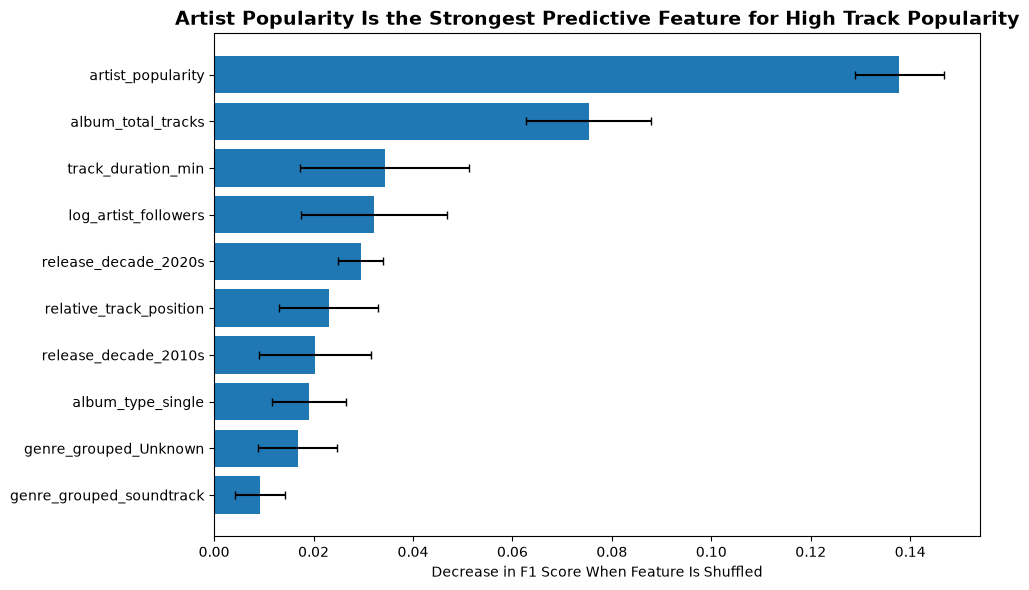

In [213]:
top_perm = (
    perm_results
    .head(10)
    .sort_values("Importance_Mean")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_perm["Feature"],
    top_perm["Importance_Mean"],
    xerr=top_perm["Importance_Std"],
    capsize=3
)

plt.title(
    "Artist Popularity Is the Strongest Predictive Feature for High Track Popularity",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Decrease in F1 Score When Feature Is Shuffled")
plt.ylabel("")

plt.tight_layout()
plt.show()

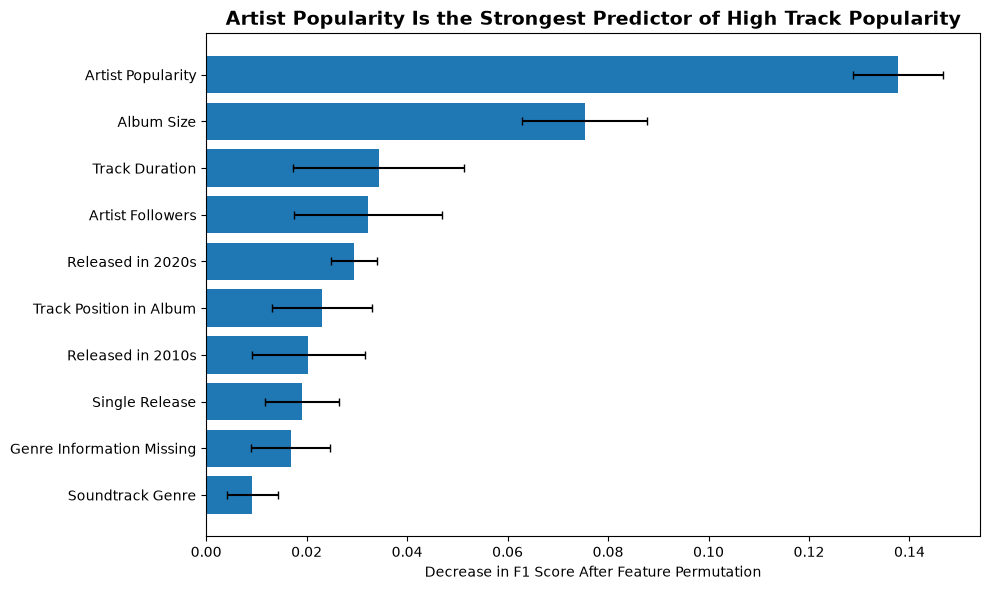

In [212]:
label_map = {
    "artist_popularity": "Artist Popularity",
    "album_total_tracks": "Album Size",
    "track_duration_min": "Track Duration",
    "log_artist_followers": "Artist Followers",
    "release_decade_2020s": "Released in 2020s",
    "relative_track_position": "Track Position in Album",
    "release_decade_2010s": "Released in 2010s",
    "album_type_single": "Single Release",
    "genre_grouped_Unknown": "Genre Information Missing",
    "genre_grouped_soundtrack": "Soundtrack Genre"
}

top_perm_plot = (
    perm_results
    .head(10)
    .copy()
)

top_perm_plot["Feature_Label"] = (
    top_perm_plot["Feature"]
    .map(label_map)
    .fillna(top_perm_plot["Feature"])
)

top_perm_plot = top_perm_plot.sort_values("Importance_Mean")

plt.figure(figsize=(10, 6))

plt.barh(
    top_perm_plot["Feature_Label"],
    top_perm_plot["Importance_Mean"],
    xerr=top_perm_plot["Importance_Std"],
    capsize=3
)

plt.title(
    "Artist Popularity Is the Strongest Predictor of High Track Popularity",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Decrease in F1 Score After Feature Permutation")
plt.ylabel("")

plt.tight_layout()
plt.show()

# Conclusion

The machine learning analysis examined whether Spotify track popularity can be predicted from track, release, genre, and artist characteristics.

## Model Performance

The majority-class Dummy model achieved approximately 73.5% accuracy, demonstrating that accuracy alone is not an appropriate measure of model quality because high-popularity tracks represent only about one quarter of the dataset.

Logistic Regression Model B achieved 74.0% accuracy, 52.5% precision, 22.2% recall, and an F1 score of 0.312 for high-popularity tracks. Its performance showed that a simple linear model captured only limited predictive signal.

Random Forest Model A, which used intrinsic track and release characteristics without artist popularity and follower information, achieved 69.4% accuracy and an F1 score of approximately 0.320. This indicates that intrinsic characteristics alone provide limited ability to identify high-popularity tracks.

Random Forest Model B added artist popularity and artist follower information and produced the strongest overall holdout performance, with 76.7% accuracy, 60.0% precision, 36.0% recall, and an F1 score of 0.450.

## Model Stability

Five-fold group-aware cross-validation was used to evaluate whether Model B's performance was dependent on a particular train-test split.

Average cross-validation performance was:

- Accuracy: 76.8%
- Precision: 57.8%
- Recall: 37.5%
- F1 score: 0.454

The small variation across folds and the similarity between the cross-validation and holdout results indicate that Model B's performance is relatively stable across different groups of tracks.

However, recall remains limited. The model identifies only about 38% of high-popularity tracks on average, meaning that most high-popularity tracks are still missed.

## Feature Importance

Held-out permutation importance showed that artist popularity was the strongest predictive feature for identifying high-popularity tracks.

Album size provided the second-largest contribution to predictive performance, followed by track duration, artist followers, recent release-period indicators, and track position within an album.

These findings reinforce the broader analytical evidence that artist-level visibility contains meaningful information associated with track popularity. However, predictive importance should not be interpreted as evidence of causation.

## Business Interpretation

The results suggest that existing artist visibility is an important component of track popularity, while track and release characteristics provide additional but more limited predictive information.

For artists, labels, and music strategy teams, this means that release decisions should not rely on individual track characteristics alone. Artist positioning, existing audience visibility, release format, timing, and other contextual factors should be considered together.

The model is therefore more useful as an analytical decision-support tool for understanding factors associated with high popularity than as a system for predicting which individual tracks will become hits.

## Limitations

Several limitations should be considered when interpreting the results:

- The high-popularity target was defined using a project-specific top-quartile threshold.
- Spotify track popularity reflects popularity observed in the dataset rather than popularity measured at the original release date.
- Genre information is missing for a substantial proportion of tracks.
- The dataset may not capture important drivers such as playlist placement, marketing expenditure, social media activity, radio exposure, geographic audience behavior, or changes in popularity over time.
- Predictive relationships identified by the models do not establish causal effects.

Future analysis could incorporate time-based popularity observations, playlist exposure, promotional activity, and other market-level variables to evaluate track performance more comprehensively.